In [4]:

try:
    import torch
    print("PyTorch is installed:", torch.__version__)
except ImportError:
    print("PyTorch is NOT installed.")

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    a = torch.randn(1024,1024, device="cuda"); b = torch.mm(a, a.t()); print("OK:", b.is_cuda, b.shape)



PyTorch is installed: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
OK: True torch.Size([1024, 1024])


In [13]:
import os
from torch.utils.data import Subset
import torch
from torch.cuda.amp import autocast, GradScaler
import random
import numpy as np
from torchinfo import summary
import tensorflow as tf
import rasterio as rio
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio as rio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchview import draw_graph


c:\Users\omara\Desktop\project_deep_machine_learning\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_dir = Path('../CV_new/AI_design/lab5/Potsdam-GeoTif/Potsdam-GeoTif')
all_files = sorted([str(p) for p in data_dir.glob("*.tif")]) 
print(f"Found {len(all_files)} tiles in source.")




Found 15048 tiles in source.


In [7]:
random.seed(42)
n = len(all_files)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# 1) Train vs temp (70% / 30%)
train_files, temp_files = train_test_split(
    all_files, test_size=0.30, random_state=42, shuffle=True
)

# 2) Temp -> Val/Test (split 30% into 15%/15% => 50/50 of temp)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train: {len(train_files)}  ({len(train_files)/len(all_files)*100:.1f}%)")
print(f"Val  : {len(val_files)}   ({len(val_files)/len(all_files)*100:.1f}%)")
print(f"Test : {len(test_files)}  ({len(test_files)/len(all_files)*100:.1f}%)")


Train: 10533  (70.0%)
Val  : 2257   (15.0%)
Test : 2258  (15.0%)


In [ ]:


# ---------- Albumentations helpers ----------
# Photometric sub-pipeline that we will apply ONLY to RGB+IR
photo_tf = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.5),
    A.RandomGamma(gamma_limit=(90,110), p=0.3),
   # A.GaussNoise(var_limit=(1e-5, 5e-4), p=0.2)
   #A.GaussNoise(std_range=(0.003, 0.022), mean_range=(0.0, 0.0), p=0.2)
])

def apply_photo_on_rgbir(image: np.ndarray, noise_std_range=(1e-3, 5e-3), **kwargs) -> np.ndarray:
    rgbir = image[..., :4]
    dsm   = image[..., 4:]

    # photometric on RGB+IR
    rgbir = photo_tf(image=rgbir)["image"]

    # add gaussian noise on RGB+IR only
    std = np.random.uniform(*noise_std_range)
    noise = np.random.normal(loc=0.0, scale=std, size=rgbir.shape).astype(np.float32)
    rgbir = np.clip(rgbir + noise, 0.0, 1.0)

    return np.concatenate([rgbir, dsm], axis=-1)




class PotsdamTiffDataset(Dataset):
    def __init__(self, file_list, transform=None, normalize=True):
        self.files = list(file_list)
        self.transform = transform      
        self.normalize = normalize

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        with rio.open(p) as src:
            arr = src.read()                      # (C,H,W)
            arr = np.transpose(arr, (1,2,0))      # (H,W,C)
            img  = arr[..., :5].astype(np.float32)  # [R,G,B,IR,DSM]
            mask = arr[..., 5].astype(np.int64)     # class ids

        # Normalize: RGB+IR -> [0,1]; DSM -> per-tile standardization + clipping
        if self.normalize:
            # RGB + IR
            img[..., :4] /= 255.0

            # DSM (channel 4): z-score then clip
            dsm = img[..., 4]
            m, s = dsm.mean(), dsm.std() + 1e-6
            dsm_std = (dsm - m) / s                 # <-- standardized
            img[..., 4] = np.clip(dsm_std, -5.0, 5.0)  # <-- clip standardized DSM

        # Apply your transform if provided
        if self.transform is not None:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        # To tensors
        img  = torch.from_numpy(np.transpose(img, (2,0,1))).float()  # (5,H,W)
        mask = torch.from_numpy(mask).long()                          # (H,W)
        return img, mask


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),

    # photometric only on RGB+IR via Lambda wrapper
    A.Lambda(image=apply_photo_on_rgbir, p=1.0),
])


val_transform = A.Compose([])


batch_size_train = 32
batch_size_val   = 128

raw_dataset = PotsdamTiffDataset(train_files, transform=None, normalize=True) 


train_dataset = PotsdamTiffDataset(train_files, transform=train_transform, normalize=True)
val_dataset   = PotsdamTiffDataset(val_files,   transform=val_transform,   normalize=True)
test_dataset  = PotsdamTiffDataset(test_files,  transform=val_transform,   normalize=True)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


10533
2257
2258


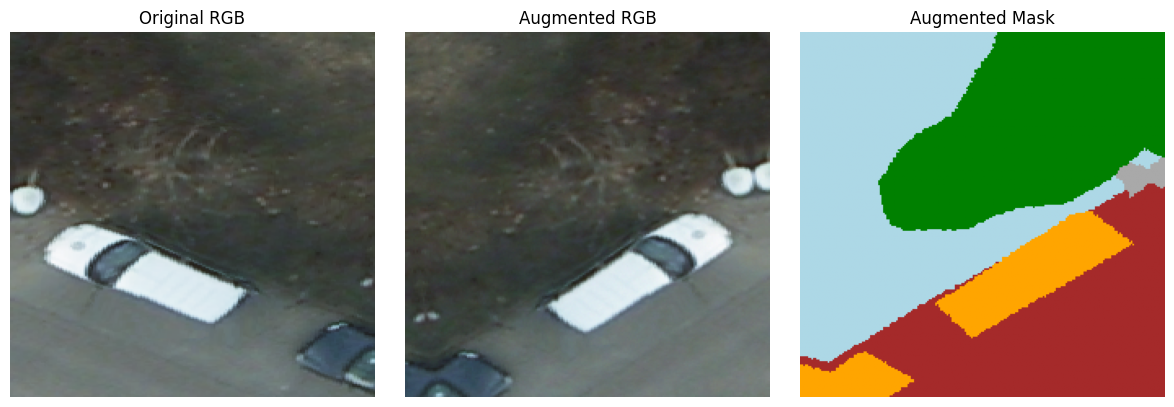

In [ ]:


idx = 3  # index
raw_img, raw_mask = raw_dataset[idx]  # no transform
aug_img, aug_mask = train_dataset[idx]  # with augmentation

# Convert tensors to numpy for visualization
raw_rgb = raw_img[:3].permute(1,2,0).numpy()
aug_rgb = aug_img[:3].permute(1,2,0).numpy()
raw_mask_np = raw_mask.numpy()
aug_mask_np = aug_mask.numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(raw_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(aug_rgb)
plt.title("Augmented RGB")
plt.axis("off")

plt.subplot(1,3,3)
class_colors = ['#A52A2A','#FFFF00','#ADD8E6','#008000','#FFA500','#A9A9A9']  # 0..5
cmap = mcolors.ListedColormap(class_colors)

plt.imshow(aug_mask_np,cmap=cmap , vmin=0, vmax=5)
plt.title("Augmented Mask")
plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size_val, shuffle=False,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size_val, shuffle=False,
                           pin_memory=True)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))




329
18
18


training loop

In [ ]:
# --- metrics
def per_class_iou(preds, labels, num_classes=6):
    """Batch-averaged mIoU (skip classes with zero union)."""
    ious = []
    for c in range(num_classes):
        inter = ((preds == c) & (labels == c)).sum().float()
        union = ((preds == c) | (labels == c)).sum().float()
        if union.item() == 0:
            continue
        ious.append(inter / union)
    return torch.stack(ious).mean().item() if ious else 0.0


def output_to_label(logits):
    """(B,C,H,W) -> (B,H,W) hard labels."""
    return torch.argmax(logits, dim=1)


def pixel_accuracy(preds, labels):
    """Mean pixel accuracy over a batch."""
    return (preds == labels).float().mean().item()


# validate (returns 5 values)
def validate(model, loss_fn, val_loader, device, num_classes=6):
    val_loss_cum, val_acc_cum = 0.0, 0.0

    # accumulators for dataset-level IoU on device (double for exactness)
    inters = torch.zeros(num_classes, dtype=torch.double, device=device)
    unions = torch.zeros(num_classes, dtype=torch.double, device=device)

    # confusion matrix built on CPU at the end of each batch
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)

    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_loss_cum += loss_fn(logits, y).item()

            preds = torch.argmax(logits, dim=1)
            val_acc_cum += (preds == y).float().mean().item()

            # IoU accumulators
            for c in range(num_classes):
                inters[c] += (((preds == c) & (y == c)).sum()).double()
                unions[c] += (((preds == c) | (y == c)).sum()).double()

            # confusion matrix via bincount
            k = (y >= 0) & (y < num_classes)
            inds = (num_classes * y[k].to(torch.int64) + preds[k].to(torch.int64)).view(-1)
            cm += torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes).cpu()

    # per-class IoU + mIoU
    inters, unions = inters.cpu(), unions.cpu()
    per_class = [(inters[c] / unions[c]).item() if unions[c].item() > 0 else float('nan')
                 for c in range(num_classes)]
    valid = [v for v in per_class if not (v != v)]  # drop NaNs
    miou = (sum(valid) / len(valid)) if valid else 0.0

    n = len(val_loader)
    return (val_loss_cum / n), (val_acc_cum / n), miou, per_class, cm


# train one epoch
def train_epoch(model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes):
    model.train()
    train_loss_batches, train_acc_batches = [], []
    num_batches = len(train_loader)

    for batch_index, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_batches.append(loss.item())
        preds = output_to_label(logits)
        train_acc_batches.append(pixel_accuracy(preds, y))

        if print_every is not None and batch_index % print_every == 0:
            v_loss, v_acc, v_miou, v_per_class, _ = validate(model, loss_fn, val_loader, device, num_classes)
            model.train()
            print(
                f"\tBatch {batch_index}/{num_batches}: "
                f"\tTrain loss: {sum(train_loss_batches[-print_every:])/print_every:.3f}, "
                f"\tTrain acc.: {sum(train_acc_batches[-print_every:])/print_every:.3f}, "
                f"\tVal. loss: {v_loss:.3f}, "
                f"\tVal. acc.: {v_acc:.3f}, "
                f"\tVal. mIoU: {v_miou:.3f}"
            )
            print("\tVal. per-class IoU:", [None if (v!=v) else round(v, 3) for v in v_per_class])

    return model, train_loss_batches, train_acc_batches


# top-level loop here SAVES per-class IoU & CM per epoch
def training_loop_with_iou_per_class(model, optimizer, loss_fn, train_loader, val_loader,
                                     num_epochs, print_every=None, num_classes=6):
    print("Starting training")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, train_accs, val_losses, val_accs, val_mious = [], [], [], [], []
    val_per_class_history = []  # NEW: list of lists, shape (E, C)
    cm_history = []             # NEW: list of CxC tensors

    for epoch in range(1, num_epochs + 1):
        model, train_loss, train_acc = train_epoch(
            model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes
        )
        val_loss, val_acc, val_miou, val_per_class, cm = validate(
            model, loss_fn, val_loader, device, num_classes
        )

        print(
            f"Epoch {epoch}/{num_epochs}: "
            f"Train loss: {sum(train_loss)/len(train_loss):.3f}, "
            f"Train acc.: {sum(train_acc)/len(train_acc):.3f}, "
            f"Val. loss: {val_loss:.3f}, "
            f"Val. acc.: {val_acc:.3f}, "
            f"Val. mIoU: {val_miou:.3f}"
        )
        print("Val per-class IoU:", [None if (v!=v) else round(v, 3) for v in val_per_class])
       

        # save histories
        train_losses.extend(train_loss)
        train_accs.extend(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_mious.append(val_miou)
        val_per_class_history.append([float(v) for v in val_per_class])  
        cm_history.append(cm.clone()) 

    # return the new histories
    return (model, train_losses, train_accs, val_losses, val_accs,
            val_mious, val_per_class_history, cm_history)


# 1: Basline model:

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, 3, padding=1)  # <-- raw logits, CS has sofmax internally
        )

    def forward(self, x):
        return self.conv(x)
    



# without weights in the loss_function

In [ ]:

no_w_basic_model = DoubleConv(5, 6)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(no_w_basic_model.parameters(), lr=1e-3, weight_decay=1e-5)  


model_no_w, no_w_train_losses, no_w_train_accs, no_w_val_losses, no_w_val_accs, no_w_val_mious, no_w_val_per_class_history, no_w_cm_history = training_loop_with_iou_per_class(
    no_w_basic_model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=10, print_every=100, num_classes=6
)
print("Val mIoU by epoch:", [round(x, 4) for x in no_w_val_mious])



Starting training
	Batch 100/329: 	Train loss: 1.258, 	Train acc.: 0.567, 	Val. loss: 1.138, 	Val. acc.: 0.614, 	Val. mIoU: 0.301
	Batch 200/329: 	Train loss: 1.096, 	Train acc.: 0.619, 	Val. loss: 1.060, 	Val. acc.: 0.636, 	Val. mIoU: 0.312
	Batch 300/329: 	Train loss: 1.070, 	Train acc.: 0.624, 	Val. loss: 1.041, 	Val. acc.: 0.629, 	Val. mIoU: 0.314
Epoch 1/10: Train loss: 1.134, Train acc.: 0.605, Val. loss: 1.007, Val. acc.: 0.640, Val. mIoU: 0.319
	Batch 100/329: 	Train loss: 1.032, 	Train acc.: 0.625, 	Val. loss: 0.996, 	Val. acc.: 0.644, 	Val. mIoU: 0.335
	Batch 200/329: 	Train loss: 0.999, 	Train acc.: 0.639, 	Val. loss: 0.988, 	Val. acc.: 0.629, 	Val. mIoU: 0.300
	Batch 300/329: 	Train loss: 0.992, 	Train acc.: 0.632, 	Val. loss: 0.986, 	Val. acc.: 0.643, 	Val. mIoU: 0.328
Epoch 2/10: Train loss: 1.006, Train acc.: 0.632, Val. loss: 0.951, Val. acc.: 0.645, Val. mIoU: 0.324
	Batch 100/329: 	Train loss: 0.964, 	Train acc.: 0.640, 	Val. loss: 0.971, 	Val. acc.: 0.636, 	Val. mIoU

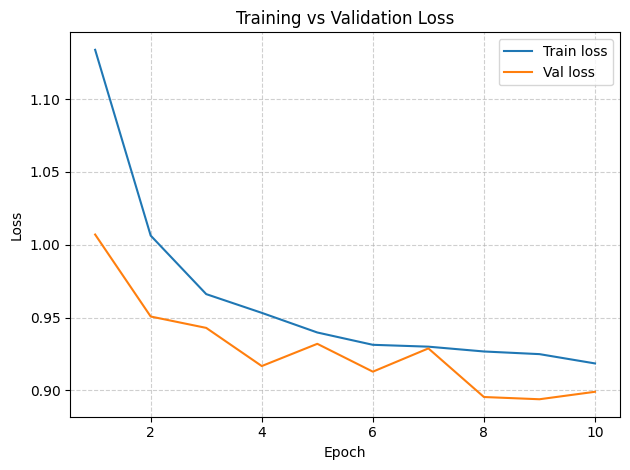

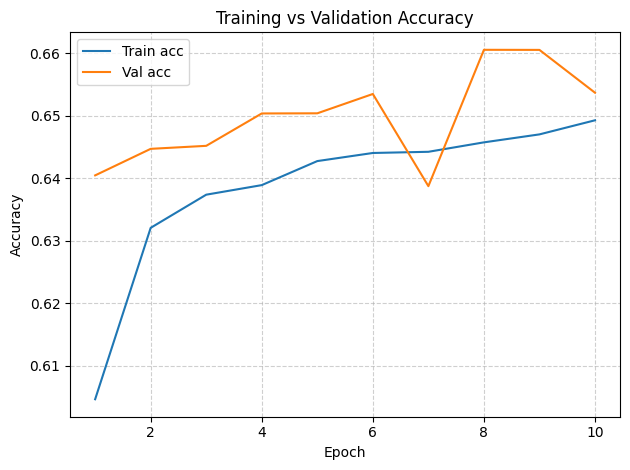

In [ ]:
def plot_curves(train_losses, train_accs, val_losses, val_accs):
    n_epochs = len(val_losses)
    steps_per_epoch = len(train_losses) // n_epochs
    
    usable = steps_per_epoch * n_epochs
    train_loss_epoch = np.array(train_losses[:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)
    train_acc_epoch  = np.array(train_accs [:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)

    epochs = np.arange(1, n_epochs + 1)

    # Loss
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.plot(epochs, val_losses,      label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig("loss_curve_without_weights.png")
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_accs,        label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig("acc_curve_without_weights.png")
    
    
    plt.show()

plot_curves(no_w_train_losses, no_w_train_accs, no_w_val_losses, no_w_val_accs)

torch.save(
    {
        "model_state_dict": model_no_w.state_dict(),
        "train_losses": no_w_train_losses,
        "train_accs": no_w_train_accs,
        "val_losses": no_w_val_losses,
        "val_accs": no_w_val_accs,
        "val_miou": no_w_val_mious,
        "val_per_class_history":no_w_val_per_class_history,
        "cm_history":no_w_cm_history


    },
    "./first_model_no_w.ckpt",
)




In [ ]:
# inverse-frequency weighting
def get_class_weights(train_loader, num_classes=6):
    counts = torch.zeros(num_classes, dtype=torch.float)
    for _, y in train_loader:
        y = y.view(-1)
        counts += torch.bincount(y, minlength=num_classes)
    # inverse-frequency weighting
    weights = 1.0 / (counts + 1e-9)
    return weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6


weights = get_class_weights(train_loader, num_classes)
weights = weights.to(device)


basic_model = DoubleConv(5, 6)
criterion   = nn.CrossEntropyLoss(weight=weights)
optimizer   = torch.optim.Adam(basic_model.parameters(), lr=1e-3, weight_decay=1e-5)  



model_efter_traning_weights, w_tr_loss, w_tr_acc, w_val_loss, w_val_acc, w_val_miou, val_per_class_history, cm_history = training_loop_with_iou_per_class(
    basic_model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=10, print_every=100, num_classes=num_classes
)
print("Val mIoU by epoch:", [round(x, 4) for x in w_val_miou])


Starting training
	Batch 100/329: 	Train loss: 1.442, 	Train acc.: 0.436, 	Val. loss: 1.348, 	Val. acc.: 0.357, 	Val. mIoU: 0.205
	Val. per-class IoU: [0.165, 0.144, 0.465, 0.306, 0.031, 0.12]
	Batch 200/329: 	Train loss: 1.281, 	Train acc.: 0.507, 	Val. loss: 1.227, 	Val. acc.: 0.532, 	Val. mIoU: 0.316
	Val. per-class IoU: [0.466, 0.404, 0.461, 0.32, 0.069, 0.175]
	Batch 300/329: 	Train loss: 1.227, 	Train acc.: 0.533, 	Val. loss: 1.204, 	Val. acc.: 0.613, 	Val. mIoU: 0.354
	Val. per-class IoU: [0.549, 0.574, 0.43, 0.34, 0.132, 0.101]
Epoch 1/10: Train loss: 1.306, Train acc.: 0.497, Val. loss: 1.206, Val. acc.: 0.472, Val. mIoU: 0.275
Val per-class IoU: [0.396, 0.46, 0.254, 0.367, 0.058, 0.113]
	Batch 100/329: 	Train loss: 1.172, 	Train acc.: 0.558, 	Val. loss: 1.120, 	Val. acc.: 0.603, 	Val. mIoU: 0.366
	Val. per-class IoU: [0.555, 0.506, 0.441, 0.359, 0.167, 0.166]
	Batch 200/329: 	Train loss: 1.149, 	Train acc.: 0.570, 	Val. loss: 1.128, 	Val. acc.: 0.558, 	Val. mIoU: 0.336
	Val. 


(process:21624): Pango-WARNING **: 00:52:21.880: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


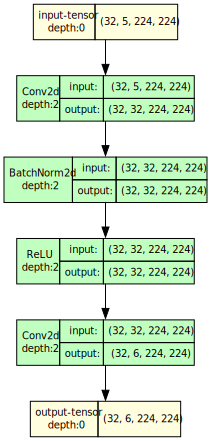

In [ ]:
summary(basic_model, input_size=(batch_size_train,5,224, 224 ))
from torchview import draw_graph
model_graph = draw_graph(basic_model,input_size=(32, 5, 224,224))
model_graph.visual_graph 

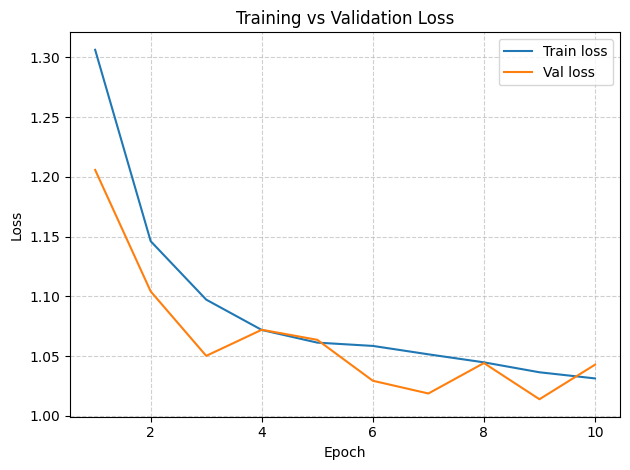

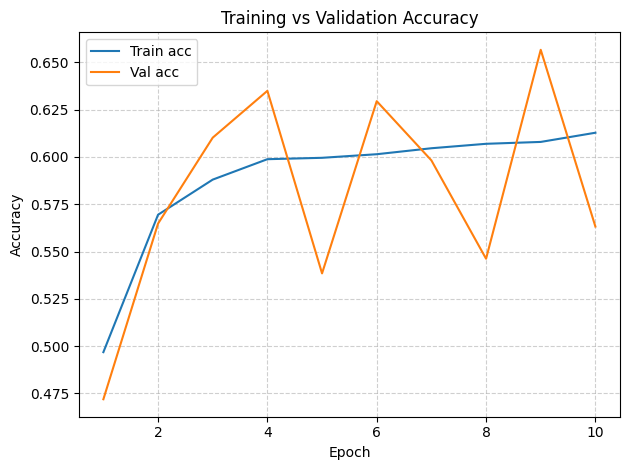

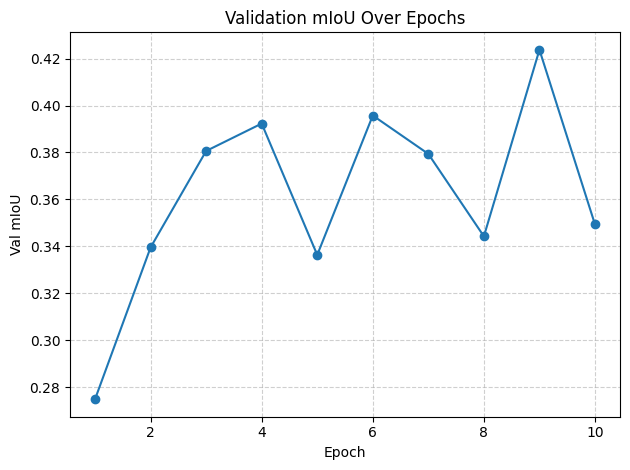

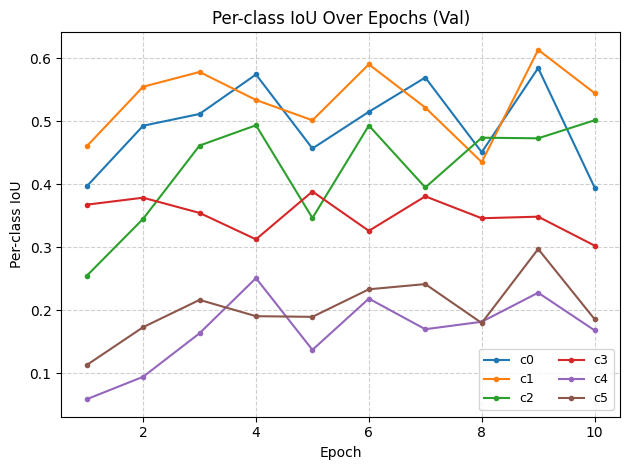

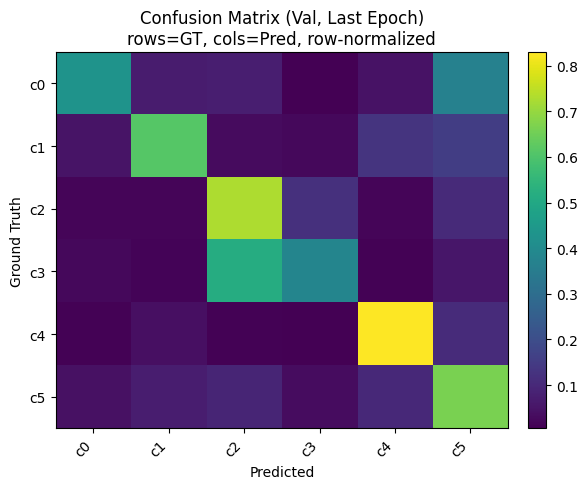

In [ ]:
def plot_curves(train_losses, train_accs, val_losses, val_accs):
    n_epochs = len(val_losses)
    steps_per_epoch = len(train_losses) // n_epochs
    
    usable = steps_per_epoch * n_epochs
    train_loss_epoch = np.array(train_losses[:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)
    train_acc_epoch  = np.array(train_accs [:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)

    epochs = np.arange(1, n_epochs + 1)
   

    #  Loss
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.plot(epochs, val_losses,      label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig("loss_curve_with_weights.png")
    

    plt.show()

    # Accuracy 
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_accs,        label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig("acc_curve_with_weights.png")
    plt.show()



plot_curves( w_tr_loss, w_tr_acc, w_val_loss, w_val_acc)



def plot_key_metrics(w_val_miou, val_per_class_history, cm_history, class_names=None, prefix="weighted"):

    # 1) mIoU over epochs 
    epochs = np.arange(1, len(w_val_miou) + 1)
    plt.figure()
    plt.plot(epochs, w_val_miou, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Val mIoU")
    plt.title("Validation mIoU Over Epochs")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_miou_curve.png", dpi=150)
    plt.show()

    #2) Per-class IoU over epochs 
    per_class = np.array(val_per_class_history, dtype=float)  # (E, C) with possible NaNs
    num_classes = per_class.shape[1]
    if class_names is None:
        class_names = [f"c{i}" for i in range(num_classes)]

    plt.figure()
    for c in range(num_classes):
        plt.plot(epochs, per_class[:, c], marker=".", label=class_names[c])
    plt.xlabel("Epoch")
    plt.ylabel("Per-class IoU")
    plt.title("Per-class IoU Over Epochs (Val)")
    plt.legend(ncols=2, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_perclass_iou_curve.png", dpi=150)
    plt.show()

    # 3) Normalized confusion matrix 
    cm = cm_history[-1].cpu().numpy().astype(float)  # (C, C)
    row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
    cm_norm = cm / row_sums

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
    plt.title("Confusion Matrix (Val, Last Epoch)\nrows=GT, cols=Pred, row-normalized")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_positions = np.arange(num_classes)
    plt.xticks(tick_positions, class_names, rotation=45, ha="right")
    plt.yticks(tick_positions, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion_matrix_last_epoch.png", dpi=150)
    plt.show()


plot_key_metrics(
    w_val_miou,
    val_per_class_history,
    cm_history,
    class_names=None,        
    prefix="weighted_ce_run" 
)



torch.save(
    {
        "model_state_dict": model_efter_traning_weights.state_dict(),
        "train_losses": w_tr_loss,
        "train_accs": w_tr_acc,
        "val_losses": w_val_loss,
        "val_accs": w_val_acc,
        "val_miou": w_val_miou,
        "val_per_class_history":val_per_class_history,
        "cm_history":cm_history


    },
    "./first_with_weights.ckpt",
)





In [ ]:
# Extract F1-scores from confusion matrices

def per_class_f1_from_cm(confusion_matrix, num_classes=6):
    f1_scores = []
    
    for c in range(num_classes):
        # True Positives: diagonal element
        tp = confusion_matrix[c, c].item()
        
        # False Positives: sum of column c 
        fp = confusion_matrix[:, c].sum().item() - tp
        
        # False Negatives: sum of row c 
        fn = confusion_matrix[c, :].sum().item() - tp
        
        # Precision and Recall
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        # F1-score
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0
        
        f1_scores.append(f1)
    
    # Macro F1 (average across classes)
    macro_f1 = sum(f1_scores) / len(f1_scores)
    
    return f1_scores, macro_f1


def extract_f1_history(cm_history, num_classes=6):
 
    f1_history = []
    macro_f1_history = []
    
    for cm in cm_history:
        per_class_f1, macro_f1 = per_class_f1_from_cm(cm, num_classes)
        f1_history.append(per_class_f1)
        macro_f1_history.append(macro_f1)
    
    return f1_history, macro_f1_history



ckpt = torch.load("first_with_weights.ckpt", map_location="cpu")
w_cm_his = ckpt["cm_history"]
w_val_miou   = ckpt["val_miou"]




w_f1_history, w_macro_f1_history = extract_f1_history(w_cm_his, num_classes=6)

print(f"\n 2conv Final Results:")
print(f"  mIoU:     {w_val_miou[-1]:.3f}")
print(f"  Macro F1: {w_macro_f1_history[-1]:.3f}")


 2conv Final Results:
  mIoU:     0.349
  Macro F1: 0.501


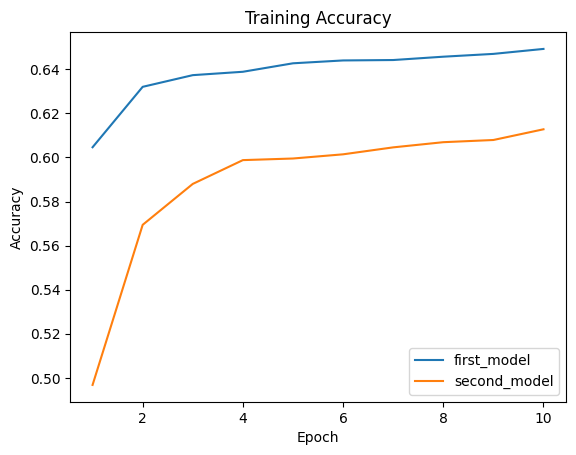

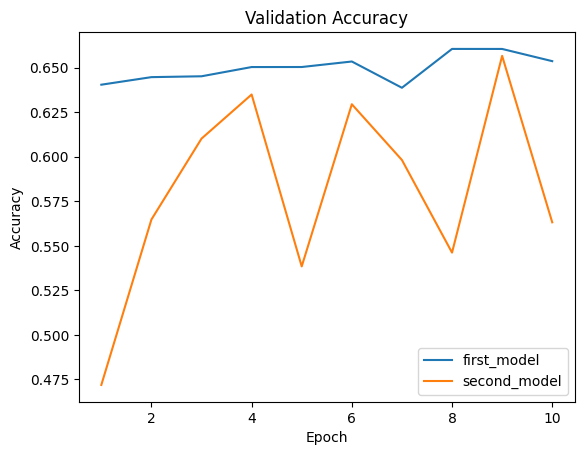

In [ ]:
def _avg_per_epoch(train_accs, val_accs):
  
    n_epochs = len(val_accs)
    steps = len(train_accs) // n_epochs
    
    train_accs = train_accs[: steps * n_epochs]
    # average train accuracy per epoch
    train_epoch = [
        sum(train_accs[i*steps:(i+1)*steps]) / steps
        for i in range(n_epochs)
    ]
    return train_epoch, val_accs

def plot_compare_acc(first_train_accs, first_val_accs,
                     second_train_accs, second_val_accs,
                     first_name="First CNN", second_name="Second CNN"):
    f_train_ep, f_val_ep = _avg_per_epoch(first_train_accs, first_val_accs)
    s_train_ep, s_val_ep = _avg_per_epoch(second_train_accs, second_val_accs)
    epochs = range(1, len(first_val_accs) + 1)

    # Training accuracy
    plt.figure()
    plt.plot(epochs, f_train_ep, label=first_name)
    plt.plot(epochs, s_train_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.legend()
    plt.show()

    # Validation accuracy
    plt.figure()
    plt.plot(epochs, f_val_ep, label=first_name)
    plt.plot(epochs, s_val_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    plt.show()




ckpt = torch.load("first_model.ckpt", map_location="cpu")
first_train_accs = ckpt["train_accs"]
first_val_accs   = ckpt["val_accs"]


plot_compare_acc(first_train_accs, first_val_accs,
                 w_tr_acc, w_val_acc,
                 first_name="first_model", second_name="second_model")


# 2: Second model:

In [22]:


class PotsdamSegNet(nn.Module):
    def __init__(self, in_channels=5, num_classes=6):
        super().__init__()

        # Encoder
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.bottleneck = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_skip1 = nn.Conv2d(128, 64, kernel_size=3, padding=1)  # after concat with skip

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_skip2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)

       
        self.final_conv = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # Output (no softmax here — handled by CrossEntropyLoss)
        self.out_conv = nn.Conv2d(32, num_classes, kernel_size=3, padding=1)

    def forward(self, x):
        # Encoder
        x1 = F.relu(self.conv1(x))
        x1p = self.pool1(x1)

        x2 = F.relu(self.conv2(x1p))
        x2p = self.pool2(x2)

        x3 = F.relu(self.bottleneck(x2p))

        # Decoder
        x4 = F.relu(self.upconv1(x3))
        x4_c = torch.cat([x4, x2], dim=1)
        x4_c = F.relu(self.conv_skip1(x4_c))

        x5 = F.relu(self.upconv2(x4_c))
        x5_c = torch.cat([x5, x1], dim=1)
        x5_c = F.relu(self.conv_skip2(x5_c))

        x6 = F.relu(self.final_conv(x5_c))

        # Output logits (no softmax)
        out = self.out_conv(x6)
        return out


(process:14852): Pango-WARNING **: 02:00:35.133: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


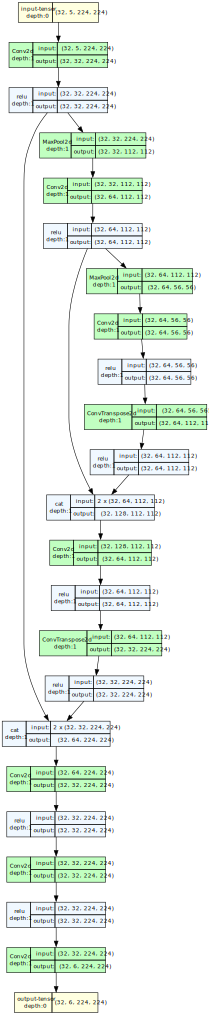

In [ ]:
def get_class_weights(train_loader, num_classes=6):
    counts = torch.zeros(num_classes, dtype=torch.float)
    for _, y in train_loader:
        y = y.view(-1)
        counts += torch.bincount(y, minlength=num_classes)
    # inverse-frequency weighting
    weights = 1.0 / (counts + 1e-9)
    return weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 6


weights = get_class_weights(train_loader, num_classes)
weights = weights.to(device)


own_model = PotsdamSegNet(in_channels=5, num_classes=6)
criterion   = nn.CrossEntropyLoss(weight=weights)
optimizer   = torch.optim.Adam(own_model.parameters(), lr=1e-3, weight_decay=1e-5)  


model_graph = draw_graph(own_model,input_size=(32, 5, 224,224))
model_graph.visual_graph 


In [ ]:
o_model_after, o_tr_loss, o_tr_acc, o_val_loss, o_val_acc, o_val_miou, o_val_per_class_history, o_cm_history = training_loop_with_iou_per_class(
    own_model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=10, print_every=100, num_classes=num_classes
)
print("Val mIoU by epoch:", [round(x, 4) for x in o_val_miou])

Starting training
	Batch 100/329: 	Train loss: 1.500, 	Train acc.: 0.469, 	Val. loss: 1.350, 	Val. acc.: 0.598, 	Val. mIoU: 0.304
	Val. per-class IoU: [0.515, 0.513, 0.471, 0.256, 0.062, 0.004]
	Batch 200/329: 	Train loss: 1.286, 	Train acc.: 0.555, 	Val. loss: 1.201, 	Val. acc.: 0.577, 	Val. mIoU: 0.333
	Val. per-class IoU: [0.543, 0.507, 0.428, 0.319, 0.108, 0.092]
	Batch 300/329: 	Train loss: 1.213, 	Train acc.: 0.561, 	Val. loss: 1.123, 	Val. acc.: 0.587, 	Val. mIoU: 0.334
	Val. per-class IoU: [0.534, 0.552, 0.422, 0.323, 0.11, 0.064]
Epoch 1/10: Train loss: 1.321, Train acc.: 0.531, Val. loss: 1.144, Val. acc.: 0.570, Val. mIoU: 0.329
Val per-class IoU: [0.448, 0.557, 0.481, 0.307, 0.087, 0.092]
	Batch 100/329: 	Train loss: 1.134, 	Train acc.: 0.569, 	Val. loss: 1.065, 	Val. acc.: 0.604, 	Val. mIoU: 0.375
	Val. per-class IoU: [0.562, 0.509, 0.481, 0.318, 0.193, 0.189]
	Batch 200/329: 	Train loss: 1.091, 	Train acc.: 0.580, 	Val. loss: 1.090, 	Val. acc.: 0.593, 	Val. mIoU: 0.355
	V

In [ ]:
ckpt = torch.load("own_model.ckpt", map_location="cpu")
deep_cm_his = ckpt["cm_history"]
deep_val_miou   = ckpt["val_miou"]




deep_f1_history, deep_macro_f1_history = extract_f1_history(deep_cm_his, num_classes=6)

print(f"\n DeeperModel Final Results:")
print(f"  mIoU:     {deep_val_miou[-1]:.3f}")
print(f"  Macro F1: {deep_macro_f1_history[-1]:.3f}")


 DeeperModel Final Results:
  mIoU:     0.439
  Macro F1: 0.597


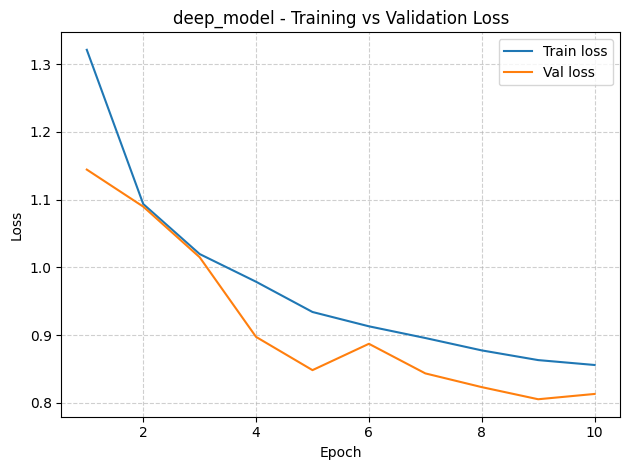

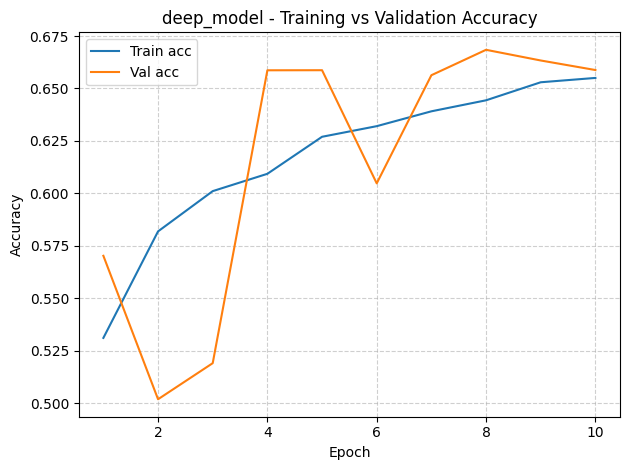

In [ ]:


def general_plot_curves(train_losses, train_accs, val_losses, val_accs, model_name="model"):
   
    n_epochs = len(val_losses)
    steps_per_epoch = len(train_losses) // n_epochs

    usable = steps_per_epoch * n_epochs
    train_loss_epoch = np.array(train_losses[:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)
    train_acc_epoch  = np.array(train_accs [:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)

    epochs = np.arange(1, n_epochs + 1)

    # Loss
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.plot(epochs, val_losses, label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_loss_curve.png")
    plt.show()

    # Accuracy 
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_accs, label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_acc_curve.png")
    plt.show()
general_plot_curves(o_tr_loss, o_tr_acc, o_val_loss, o_val_acc, model_name="deep_model")


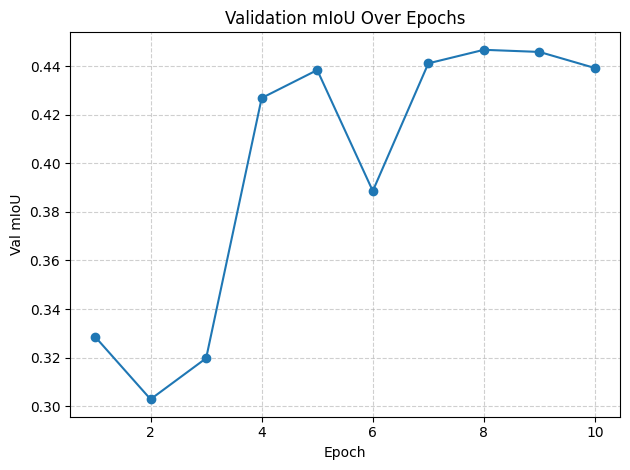

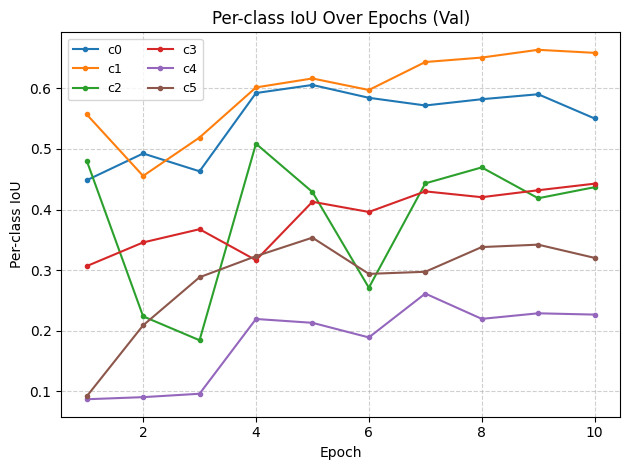

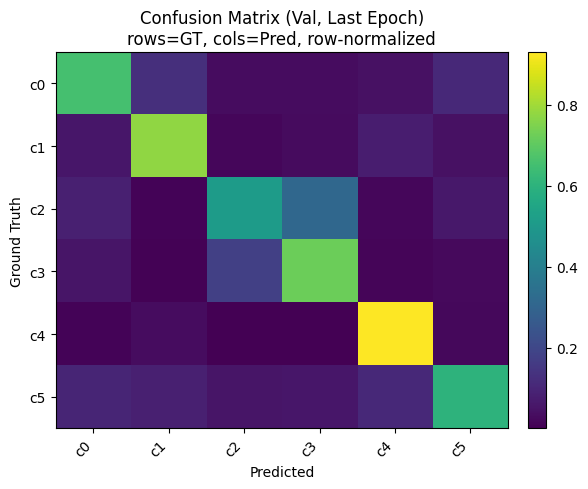

In [ ]:


def plot_key_metrics(w_val_miou, val_per_class_history, cm_history, class_names=None, prefix="weighted"):
   
    # 1) mIoU over epochs 
    epochs = np.arange(1, len(w_val_miou) + 1)
    plt.figure()
    plt.plot(epochs, w_val_miou, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Val mIoU")
    plt.title("Validation mIoU Over Epochs")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_miou_curve.png", dpi=150)
    plt.show()

    # 2) Per-class IoU over epochs 
    per_class = np.array(val_per_class_history, dtype=float)  # (E, C) with possible NaNs
    num_classes = per_class.shape[1]
    if class_names is None:
        class_names = [f"c{i}" for i in range(num_classes)]

    plt.figure()
    for c in range(num_classes):
        plt.plot(epochs, per_class[:, c], marker=".", label=class_names[c])
    plt.xlabel("Epoch")
    plt.ylabel("Per-class IoU")
    plt.title("Per-class IoU Over Epochs (Val)")
    plt.legend(ncols=2, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_perclass_iou_curve.png", dpi=150)
    plt.show()

    # 3) Normalized confusion matrix (last epoch) 
    cm = cm_history[-1].cpu().numpy().astype(float)  # (C, C)
    row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
    cm_norm = cm / row_sums

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
    plt.title("Confusion Matrix (Val, Last Epoch)\nrows=GT, cols=Pred, row-normalized")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_positions = np.arange(num_classes)
    plt.xticks(tick_positions, class_names, rotation=45, ha="right")
    plt.yticks(tick_positions, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion_matrix_last_epoch.png", dpi=150)
    plt.show()


plot_key_metrics(
    o_val_miou,
    o_val_per_class_history,
    o_cm_history,
    class_names=None,        
    prefix="weighted_ce_run"  
)


 
torch.save(
    {
        "model_state_dict": o_model_after.state_dict(),
        "train_losses": o_tr_loss,
        "train_accs": o_tr_acc,
        "val_losses": o_val_loss,
        "val_accs": o_val_acc,
        "val_miou": o_val_miou,
        "val_per_class_history":o_val_per_class_history,
        "cm_history":o_cm_history


    },
    "./own_model.ckpt",
)





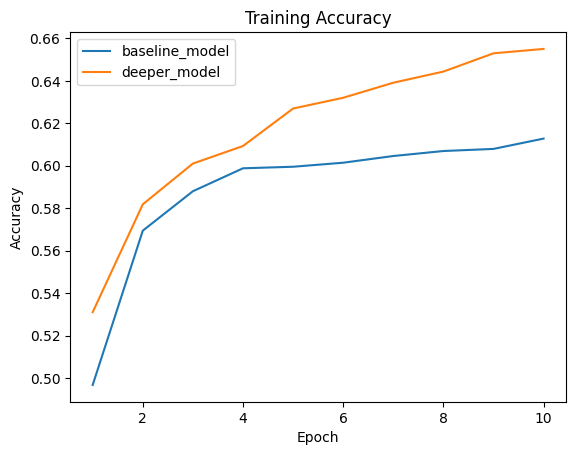

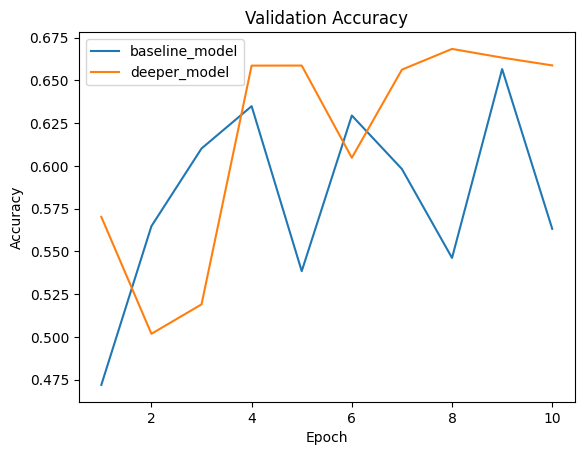

In [14]:
def _avg_per_epoch(train_accs, val_accs):
  
    n_epochs = len(val_accs)
    steps = len(train_accs) // n_epochs
    
    train_accs = train_accs[: steps * n_epochs]
    # average train accuracy per epoch
    train_epoch = [
        sum(train_accs[i*steps:(i+1)*steps]) / steps
        for i in range(n_epochs)
    ]
    return train_epoch, val_accs
def plot_compare_acc(first_train_accs, first_val_accs,
                     second_train_accs, second_val_accs,
                     first_name="First CNN", second_name="Second CNN"):
    f_train_ep, f_val_ep = _avg_per_epoch(first_train_accs, first_val_accs)
    s_train_ep, s_val_ep = _avg_per_epoch(second_train_accs, second_val_accs)
    epochs = range(1, len(first_val_accs) + 1)

    # Training accuracy
    plt.figure()
    plt.plot(epochs, f_train_ep, label=first_name)
    plt.plot(epochs, s_train_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.legend()
    plt.show()

    # Validation accuracy
    plt.figure()
    plt.plot(epochs, f_val_ep, label=first_name)
    plt.plot(epochs, s_val_ep, label=second_name)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    plt.show()
    
ckpt = torch.load("first_with_weights.ckpt", map_location="cpu")
first_train_accs = ckpt["train_accs"]
first_val_accs   = ckpt["val_accs"]



ckpt = torch.load("own_model.ckpt", map_location="cpu")
second_train_accs = ckpt["train_accs"]
second_val_accs   = ckpt["val_accs"]



plot_compare_acc(first_train_accs, first_val_accs,
                 second_train_accs, second_val_accs,
                 first_name="baseline_model", second_name="deeper_model")